#  GLOBAL HOMICIDE TRENDS ANALYSIS (1970-2025)

# 🌍 Global Homicide Analysis Notebook (1970-2025)

This notebook provides a complete analysis of global homicide trends. Below is the workflow:

1. **📚 Library Imports** – Import all necessary Python libraries.  
2. **📂 Data Loading & Inspection** – Load dataset and check structure.  
3. **📈 Descriptive Statistics** – Calculate mean, std, min, max, and trends.  
4. **🌐 Global Trend Analysis** – Visualize overall global homicide trends.  
5. **🔄 Rolling Average & Smoothing** – Smooth yearly fluctuations for clarity.  
6. **🔗 Correlation Analysis** – Check correlations between countries’ homicide rates.  
7. **🇺🇳 Individual Country Trend Analysis** – Examine trends, classify changes, measure volatility.  
8. **📅 Forecasting** – Predict future homicide rates using linear regression.  
9. **📊 Summary Dashboard (Updated & Fixed)** – 9-panel visual dashboard with key metrics.  
10. **📝 Final Summary & Key Insights** – Summarize main findings, highlight risks and improvements.  

---

### 🖼 Notebook Infographic

You can include a visual infographic for quick reference:

![Notebook Overview](notebook_overview.png)

> *This infographic highlights the workflow and key sections of the notebook in a simple, visual format.*


## **📚 Library Imports**  
   Import all necessary Python libraries

In [21]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## **📂 Data Loading and Inspection**  
   Load the dataset and inspect its structure, missing values, and basic info.


In [22]:
# ================================================================================
# Cell 2: Load and Inspect Data
# ================================================================================

# Load dataset
df = pd.read_csv('Global_Homicide_Rate_1970_2025.csv')

# Basic information
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"Years: {df['Year'].min()} - {df['Year'].max()}")
print(f"Countries: {len(df.columns) - 1}")
print("\\nFirst 5 rows:")
print(df.head())

# Data quality check
print("\\n" + "=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print("\\nData types:")
print(df.dtypes)

DATASET OVERVIEW
Shape: (56, 14)
Years: 1970 - 2025
Countries: 13
\nFirst 5 rows:
   Year  Global_Avg    USA    UK  Germany  Japan  Australia  Singapore  \
0  1970        7.02  10.22  1.54     1.32   0.78       1.03       0.79   
1  1971        7.16   9.52  1.33     1.11   0.87       1.06       0.87   
2  1972        6.84  10.34  1.51     1.27   0.75       1.05       0.79   
3  1973        7.04   9.71  1.47     1.38   0.71       1.03       0.83   
4  1974        7.16   9.40  1.38     1.16   0.83       0.95       0.79   

   South_Korea  India  China  Pakistan  South_Africa  Colombia  
0         1.08   4.19   0.98      5.29         30.06     25.14  
1         1.10   4.12   0.99      5.28         29.24     25.38  
2         1.01   3.81   1.02      5.11         30.23     26.09  
3         0.94   3.85   0.96      4.86         30.14     25.18  
4         0.95   3.86   0.92      5.16         29.28     24.79  
\n============================================================
DATA QUALITY CHECK
M

## **📈 Descriptive Statistics**  
   Calculate country-wise statistics, including mean, std, min, max, and trends.

In [23]:
# ================================================================================
# Cell 3: Descriptive Statistics
# ================================================================================

print("\\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

# Calculate statistics for all countries (excluding Year)
countries = [col for col in df.columns if col != 'Year']
stats_df = df[countries].describe().round(2)
print(stats_df)

# Country-wise summary
summary_list = []
for country in countries:
    data = df[country]
    summary_list.append({
        'Country': country,
        'Mean': data.mean(),
        'Std': data.std(),
        'Min': data.min(),
        'Max': data.max(),
        'Current_2025': data.iloc[-1],
        'Change_%': ((data.iloc[-1] - data.iloc[0]) / data.iloc[0] * 100)
    })

summary_df = pd.DataFrame(summary_list).sort_values('Mean', ascending=False)
print("\\nCountry Rankings by Average Homicide Rate:")
print(summary_df[['Country', 'Mean', 'Current_2025', 'Change_%']].round(2))

\n============================================================
DESCRIPTIVE STATISTICS
       Global_Avg    USA     UK  Germany  Japan  Australia  Singapore  \
count       56.00  56.00  56.00    56.00  56.00      56.00      56.00   
mean         6.72   8.58   1.47     1.27   0.80       1.01       0.81   
std          0.23   0.85   0.11     0.11   0.06       0.06       0.06   
min          6.29   6.89   1.31     1.11   0.70       0.91       0.70   
25%          6.54   7.86   1.37     1.19   0.76       0.97       0.78   
50%          6.72   8.54   1.48     1.25   0.80       1.02       0.81   
75%          6.89   9.29   1.57     1.36   0.86       1.05       0.86   
max          7.16  10.34   1.70     1.49   0.89       1.10       0.90   

       South_Korea  India  China  Pakistan  South_Africa  Colombia  
count        56.00  56.00  56.00     56.00         56.00     56.00  
mean          1.00   4.00   0.99      4.99         30.10     27.74  
std           0.06   0.12   0.05      0.32       

## **🌐 Global Trend Analysis**  
   Visualize overall global homicide trends and country-specific patterns.

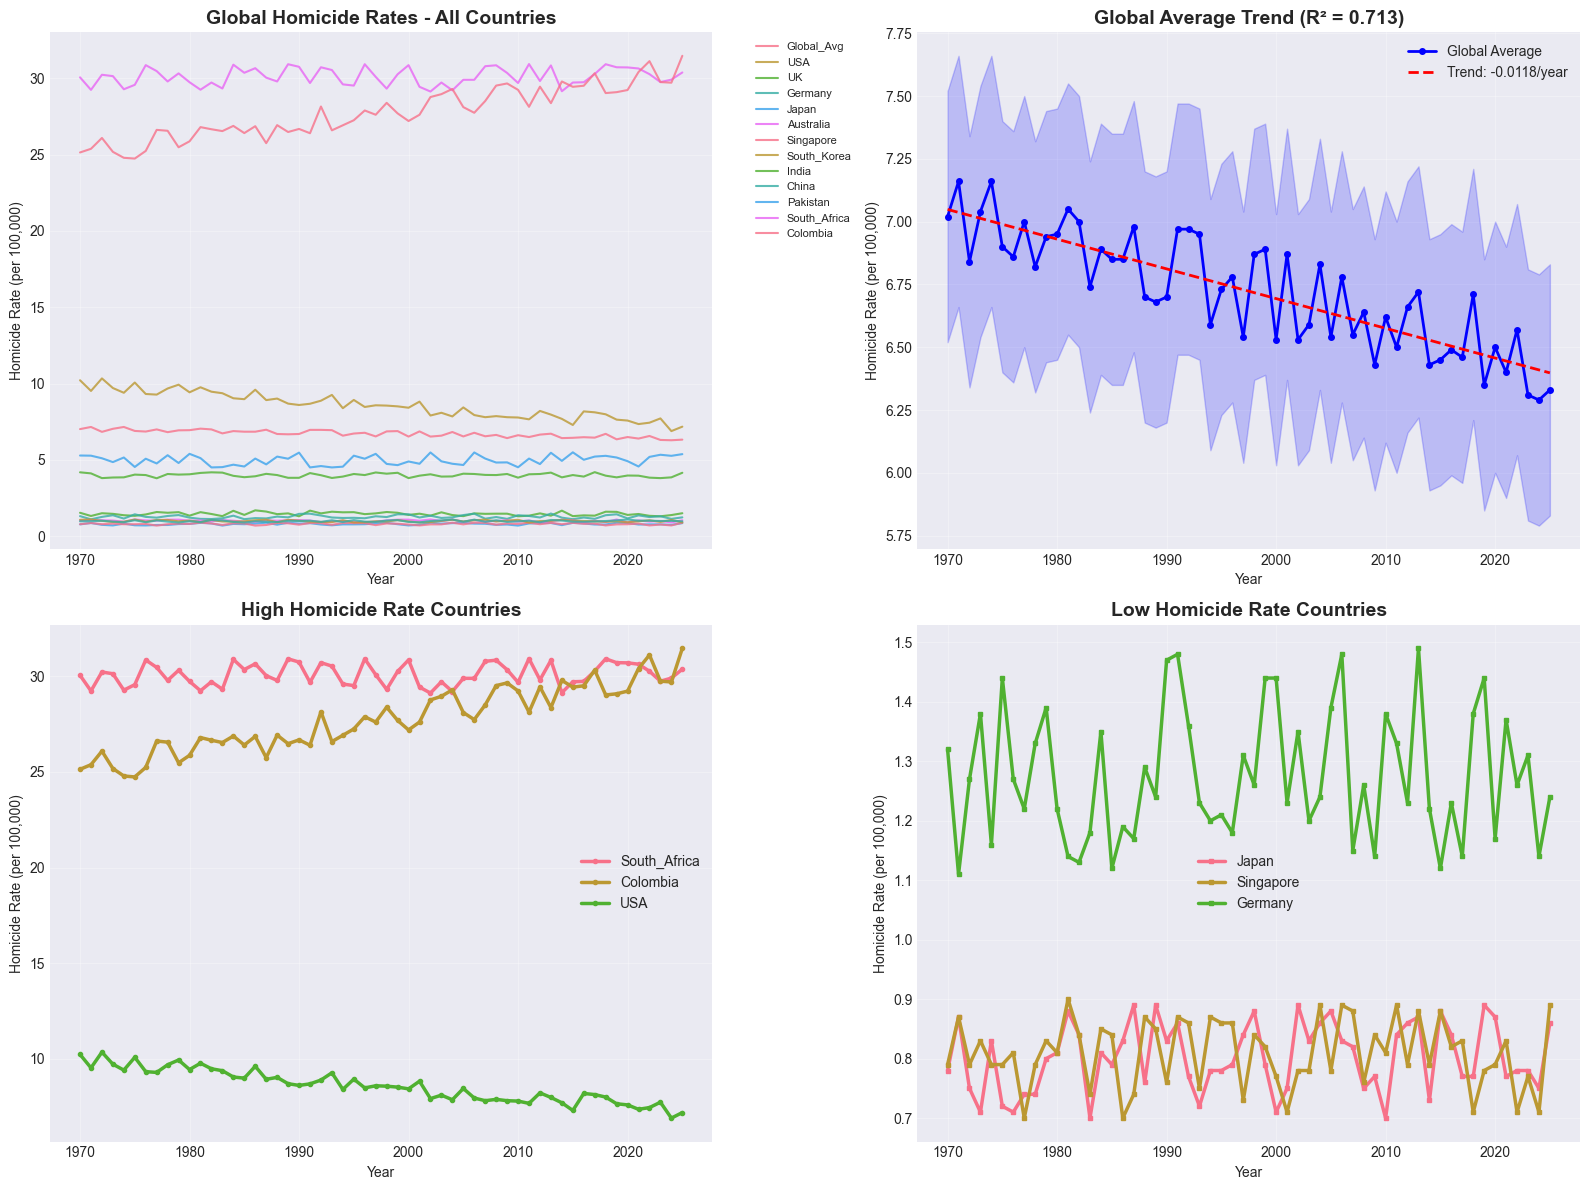

\n✅ Trend analysis visualization saved


In [24]:
# ================================================================================
# Cell 4: Global Trend Analysis
# ================================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: All countries trend
ax1 = axes[0, 0]
for country in countries:
    ax1.plot(df['Year'], df[country], label=country, linewidth=1.5, alpha=0.8)
ax1.set_title('Global Homicide Rates - All Countries', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Homicide Rate (per 100,000)')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot 2: Global average with trend line
ax2 = axes[0, 1]
x = df['Year'].values
y = df['Global_Avg'].values
ax2.plot(x, y, 'b-', linewidth=2, marker='o', markersize=4, label='Global Average')

# Linear trend
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
trend_line = slope * x + intercept
ax2.plot(x, trend_line, 'r--', linewidth=2, label=f'Trend: {slope:.4f}/year')
ax2.fill_between(x, y - 0.5, y + 0.5, alpha=0.2, color='blue')

ax2.set_title(f'Global Average Trend (R² = {r_value**2:.3f})', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Homicide Rate (per 100,000)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: High vs Low countries
ax3 = axes[1, 0]
high_countries = ['South_Africa', 'Colombia', 'USA']
low_countries = ['Japan', 'Singapore', 'Germany']

for country in high_countries:
    ax3.plot(df['Year'], df[country], linewidth=2.5, label=country, marker='o', markersize=3)
ax3.set_title('High Homicide Rate Countries', fontsize=14, fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Homicide Rate (per 100,000)')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
for country in low_countries:
    ax4.plot(df['Year'], df[country], linewidth=2.5, label=country, marker='s', markersize=3)
ax4.set_title('Low Homicide Rate Countries', fontsize=14, fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Homicide Rate (per 100,000)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('homicide_trends_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("\\n✅ Trend analysis visualization saved")

## **🔄 Rolling Average and Smoothing**  
   Apply moving averages to smooth out yearly fluctuations for clearer trends.

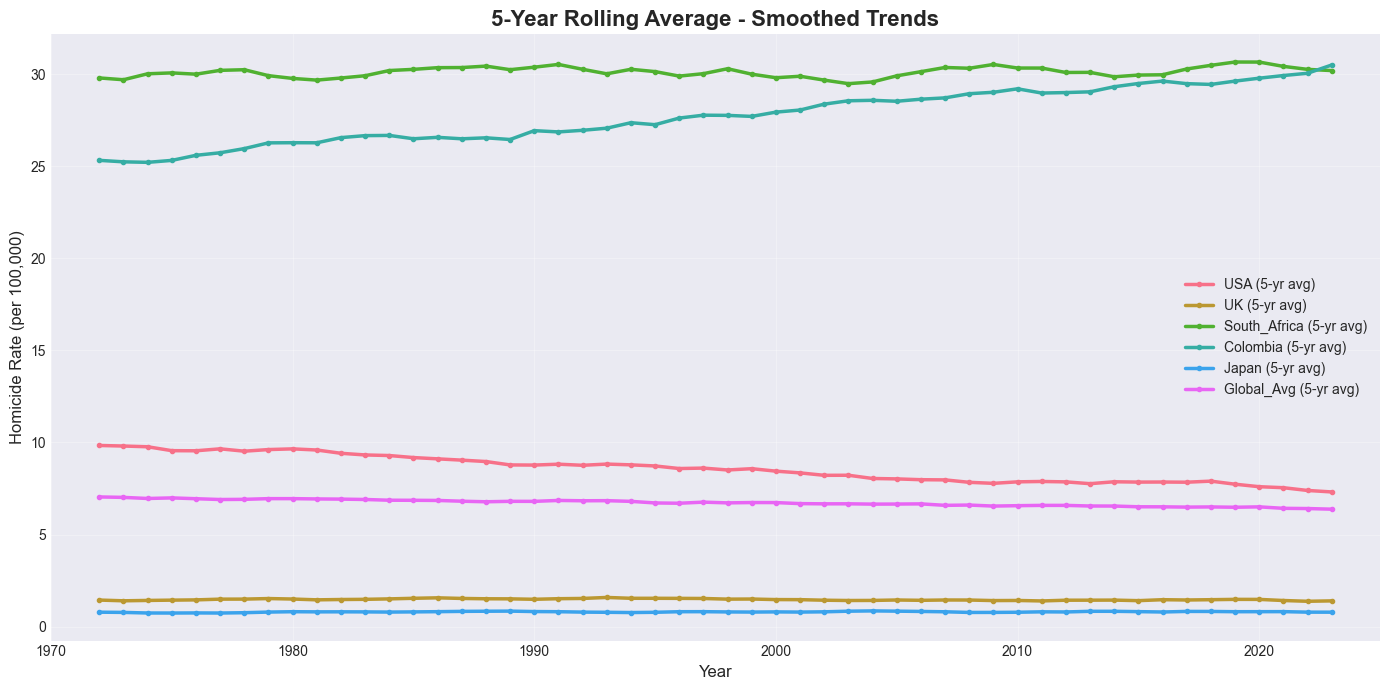

\n✅ Rolling average visualization saved


In [25]:
# ================================================================================
# Cell 5: Rolling Average and Smoothing
# ================================================================================

fig, ax = plt.subplots(figsize=(14, 7))

selected_countries = ['USA', 'UK', 'South_Africa', 'Colombia', 'Japan', 'Global_Avg']
window = 5

for country in selected_countries:
    rolling_avg = df[country].rolling(window=window, center=True).mean()
    ax.plot(df['Year'], rolling_avg, linewidth=2.5, label=f'{country} ({window}-yr avg)', marker='o', markersize=3)

ax.set_title(f'{window}-Year Rolling Average - Smoothed Trends', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Homicide Rate (per 100,000)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(1970, 2025)

plt.tight_layout()
plt.savefig('homicide_rolling_average.png', dpi=300, bbox_inches='tight')
plt.show()

print("\\n✅ Rolling average visualization saved")

## **🔗 Correlation Analysis**  
   Analyze correlations between countries' homicide rates using a heatmap.

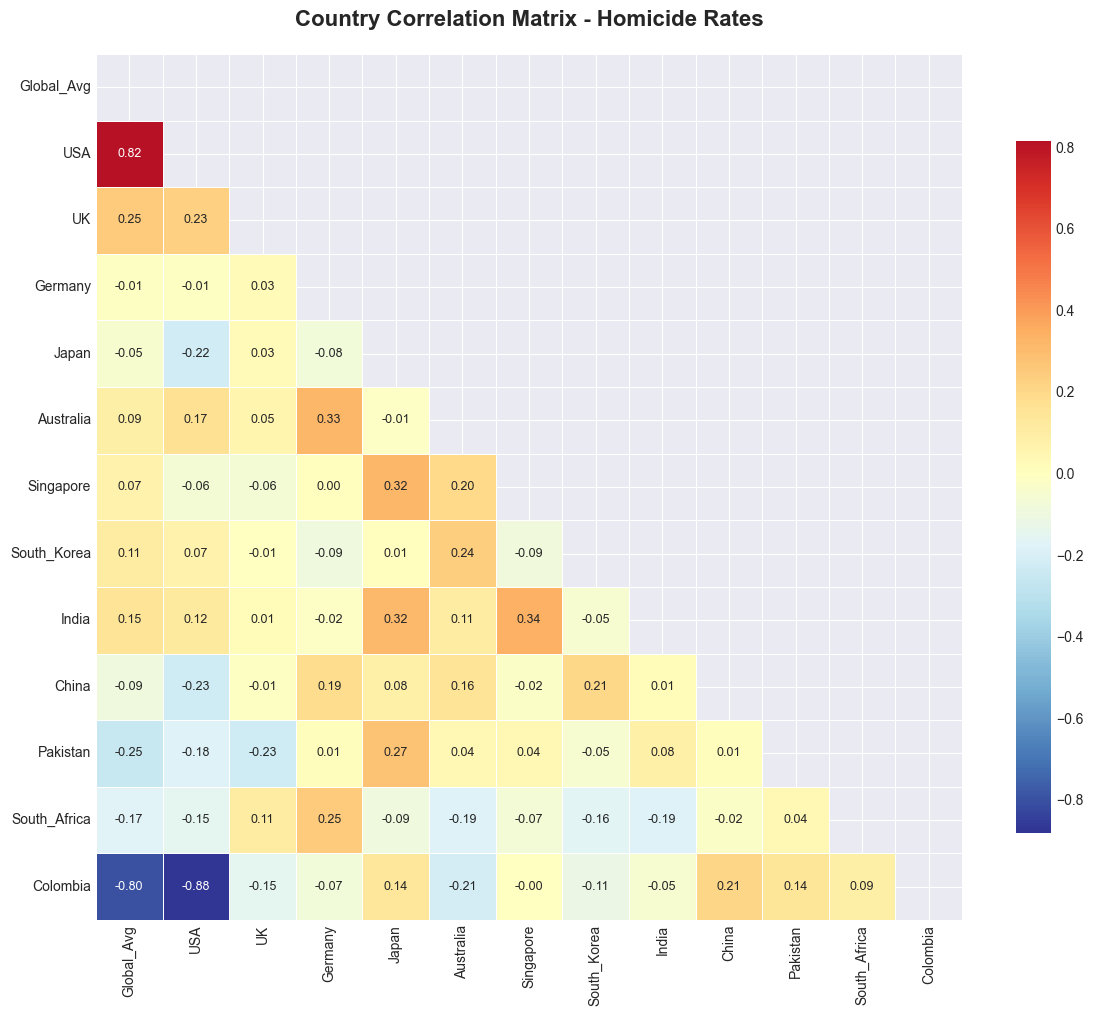

\n============================================================
STRONGEST CORRELATIONS
     Country_1  Country_2  Correlation
22         USA   Colombia       -0.883
0   Global_Avg        USA        0.817
11  Global_Avg   Colombia       -0.798
58   Singapore      India        0.343
34     Germany  Australia        0.325
43       Japan  Singapore        0.325
45       Japan      India        0.317
47       Japan   Pakistan        0.274
9   Global_Avg   Pakistan       -0.255
1   Global_Avg         UK        0.250


In [26]:
# ================================================================================
# Cell 6: Correlation Analysis
# ================================================================================

fig, ax = plt.subplots(figsize=(12, 10))

# Calculate correlation matrix
corr_matrix = df[countries].corr()

# Create heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax, annot_kws={'size': 9})
ax.set_title('Country Correlation Matrix - Homicide Rates', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('homicide_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Print strongest correlations
print("\\n" + "=" * 60)
print("STRONGEST CORRELATIONS")
print("=" * 60)
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append({
            'Country_1': corr_matrix.columns[i],
            'Country_2': corr_matrix.columns[j],
            'Correlation': corr_matrix.iloc[i, j]
        })

corr_pairs_df = pd.DataFrame(corr_pairs).sort_values('Correlation', key=abs, ascending=False)
print(corr_pairs_df.head(10).round(3))

## **🇺🇳 Individual Country Trend Analysis**  
   Examine linear trends, classify changes, and measure volatility for each country.

In [27]:
# ================================================================================
# Cell 7: Individual Country Analysis
# ================================================================================

def analyze_country_trend(country_name):
    """Analyze trend for a specific country"""
    y = df[country_name].values
    x = df['Year'].values
    
    # Linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    # Classification
    if slope < -0.05:
        trend = "Strong Decline"
    elif slope < -0.01:
        trend = "Moderate Decline"
    elif slope < 0.01:
        trend = "Stable"
    elif slope < 0.05:
        trend = "Moderate Increase"
    else:
        trend = "Strong Increase"
    
    return {
        'Country': country_name,
        'Mean': np.mean(y),
        'Slope': slope,
        'R_squared': r_value**2,
        'P_value': p_value,
        'Trend': trend,
        'Change_%': ((y[-1] - y[0]) / y[0] * 100),
        'Volatility_%': (np.std(y) / np.mean(y) * 100)
    }

# Analyze all countries
trend_results = [analyze_country_trend(c) for c in countries]
trend_df = pd.DataFrame(trend_results).sort_values('Mean', ascending=False)

print("\\n" + "=" * 80)
print("COUNTRY TREND ANALYSIS")
print("=" * 80)
print(trend_df[['Country', 'Mean', 'Trend', 'Change_%', 'Volatility_%']].round(2))

\n================================================================================
COUNTRY TREND ANALYSIS
         Country   Mean             Trend  Change_%  Volatility_%
11  South_Africa  30.10            Stable      1.06          1.87
12      Colombia  27.74   Strong Increase     25.18          6.04
1            USA   8.58  Moderate Decline    -29.75          9.83
0     Global_Avg   6.72  Moderate Decline     -9.83          3.37
10      Pakistan   4.99            Stable      1.70          6.26
8          India   4.00            Stable     -0.72          3.05
2             UK   1.47            Stable     -1.95          7.52
3        Germany   1.27            Stable     -6.06          8.50
5      Australia   1.01            Stable      1.94          5.53
7    South_Korea   1.00            Stable    -15.74          6.02
9          China   0.99            Stable      0.00          5.36
6      Singapore   0.81            Stable     12.66          6.97
4          Japan   0.80            S

## **📅 Forecasting**  
   Predict future homicide rates for key countries using linear regression.

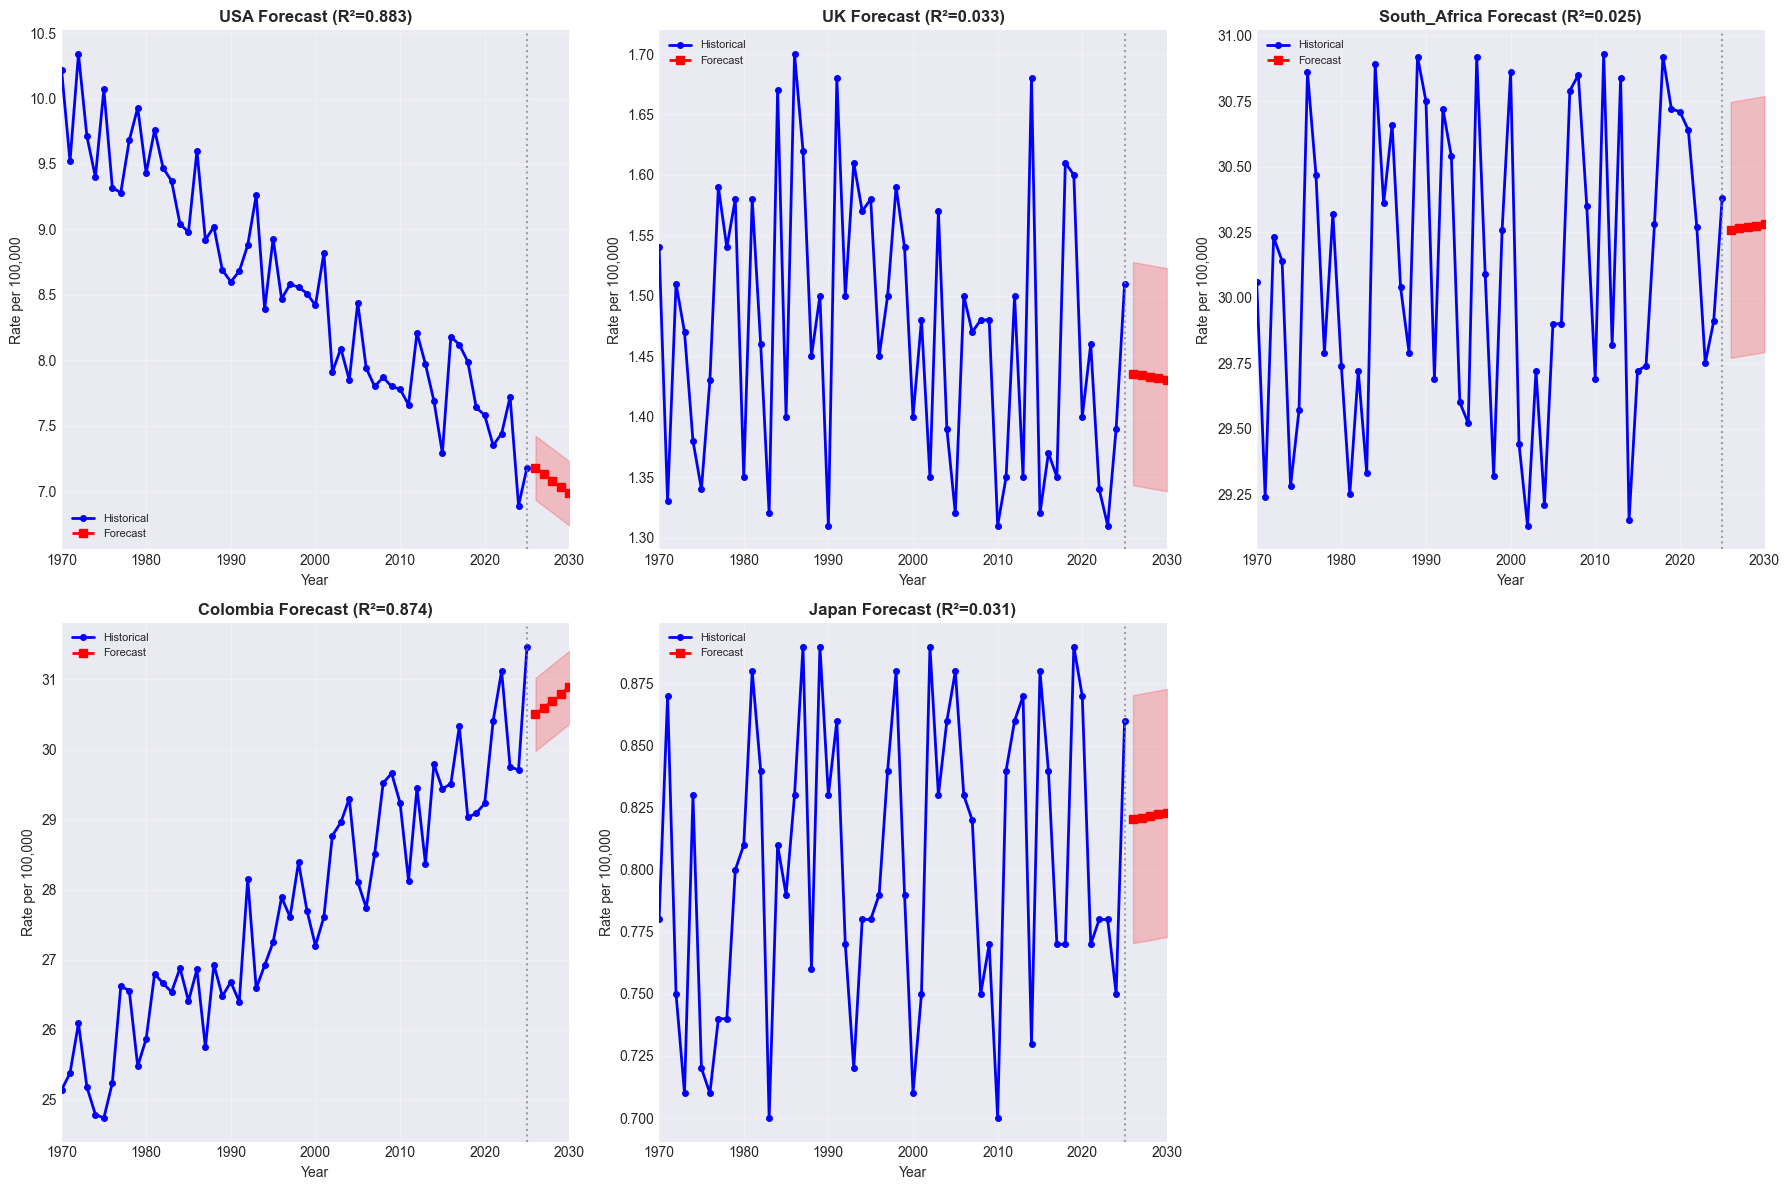

\n✅ Forecast visualization saved
\n================================================================================
5-YEAR FORECAST (2026-2030)
\nUSA (R²=0.883, MAE=0.245):
  2025 (Actual): 7.18
  2026 (Forecast): 7.18
  2027 (Forecast): 7.13
  2028 (Forecast): 7.08
  2029 (Forecast): 7.03
  2030 (Forecast): 6.98
\nUK (R²=0.033, MAE=0.092):
  2025 (Actual): 1.51
  2026 (Forecast): 1.44
  2027 (Forecast): 1.43
  2028 (Forecast): 1.43
  2029 (Forecast): 1.43
  2030 (Forecast): 1.43
\nSouth_Africa (R²=0.025, MAE=0.489):
  2025 (Actual): 30.38
  2026 (Forecast): 30.26
  2027 (Forecast): 30.26
  2028 (Forecast): 30.27
  2029 (Forecast): 30.28
  2030 (Forecast): 30.28
\nColombia (R²=0.874, MAE=0.521):
  2025 (Actual): 31.47
  2026 (Forecast): 30.50
  2027 (Forecast): 30.60
  2028 (Forecast): 30.70
  2029 (Forecast): 30.79
  2030 (Forecast): 30.89
\nJapan (R²=0.031, MAE=0.050):
  2025 (Actual): 0.86
  2026 (Forecast): 0.82
  2027 (Forecast): 0.82
  2028 (Forecast): 0.82
  2029 (Forecast): 0.8

In [28]:
# ================================================================================
# Cell 8: Forecasting
# ================================================================================

def forecast_country(country_name, years_ahead=5):
    """Simple linear forecast for a country"""
    y = df[country_name].values
    x = df['Year'].values.reshape(-1, 1)
    
    # Fit model
    model = LinearRegression()
    model.fit(x, y)
    
    # Predict future
    last_year = df['Year'].max()
    future_years = np.array(range(last_year + 1, last_year + years_ahead + 1)).reshape(-1, 1)
    predictions = model.predict(future_years)
    
    # Metrics
    y_pred = model.predict(x)
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    
    return {
        'Country': country_name,
        'R2': r2,
        'MAE': mae,
        'Future_Years': future_years.flatten(),
        'Predictions': predictions,
        'Slope': model.coef_[0]
    }

# Forecast key countries
key_countries = ['USA', 'UK', 'South_Africa', 'Colombia', 'Japan']
forecasts = {country: forecast_country(country) for country in key_countries}

# Visualize forecasts
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, country in enumerate(key_countries):
    ax = axes[idx]
    
    # Historical
    ax.plot(df['Year'], df[country], 'b-', linewidth=2, label='Historical', marker='o', markersize=4)
    
    # Forecast
    forecast_data = forecasts[country]
    ax.plot(forecast_data['Future_Years'], forecast_data['Predictions'], 
            'r--', linewidth=2, label='Forecast', marker='s', markersize=6)
    
    # Confidence interval
    mae = forecast_data['MAE']
    ax.fill_between(forecast_data['Future_Years'], 
                    forecast_data['Predictions'] - mae, 
                    forecast_data['Predictions'] + mae, 
                    alpha=0.2, color='red')
    
    # Forecast start line
    ax.axvline(x=2025, color='gray', linestyle=':', alpha=0.7)
    
    ax.set_title(f'{country} Forecast (R²={forecast_data["R2"]:.3f})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Rate per 100,000')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1970, 2030)

# Remove empty subplot
axes[5].remove()

plt.tight_layout()
plt.savefig('homicide_forecasts.png', dpi=300, bbox_inches='tight')
plt.show()

print("\\n✅ Forecast visualization saved")

# Print forecast table
print("\\n" + "=" * 80)
print("5-YEAR FORECAST (2026-2030)")
print("=" * 80)
for country in key_countries:
    f = forecasts[country]
    print(f"\\n{country} (R²={f['R2']:.3f}, MAE={f['MAE']:.3f}):")
    print(f"  2025 (Actual): {df[country].iloc[-1]:.2f}")
    for year, pred in zip(f['Future_Years'], f['Predictions']):
        print(f"  {year} (Forecast): {pred:.2f}")

## . **📊 Updated Summary Dashboard (Fixed & Fully Working)**  
   A 9-panel dashboard visualizing decade comparisons, regional averages, top & bottom countries, volatility, recent trends, distributions, correlations, box plots, and key insights.

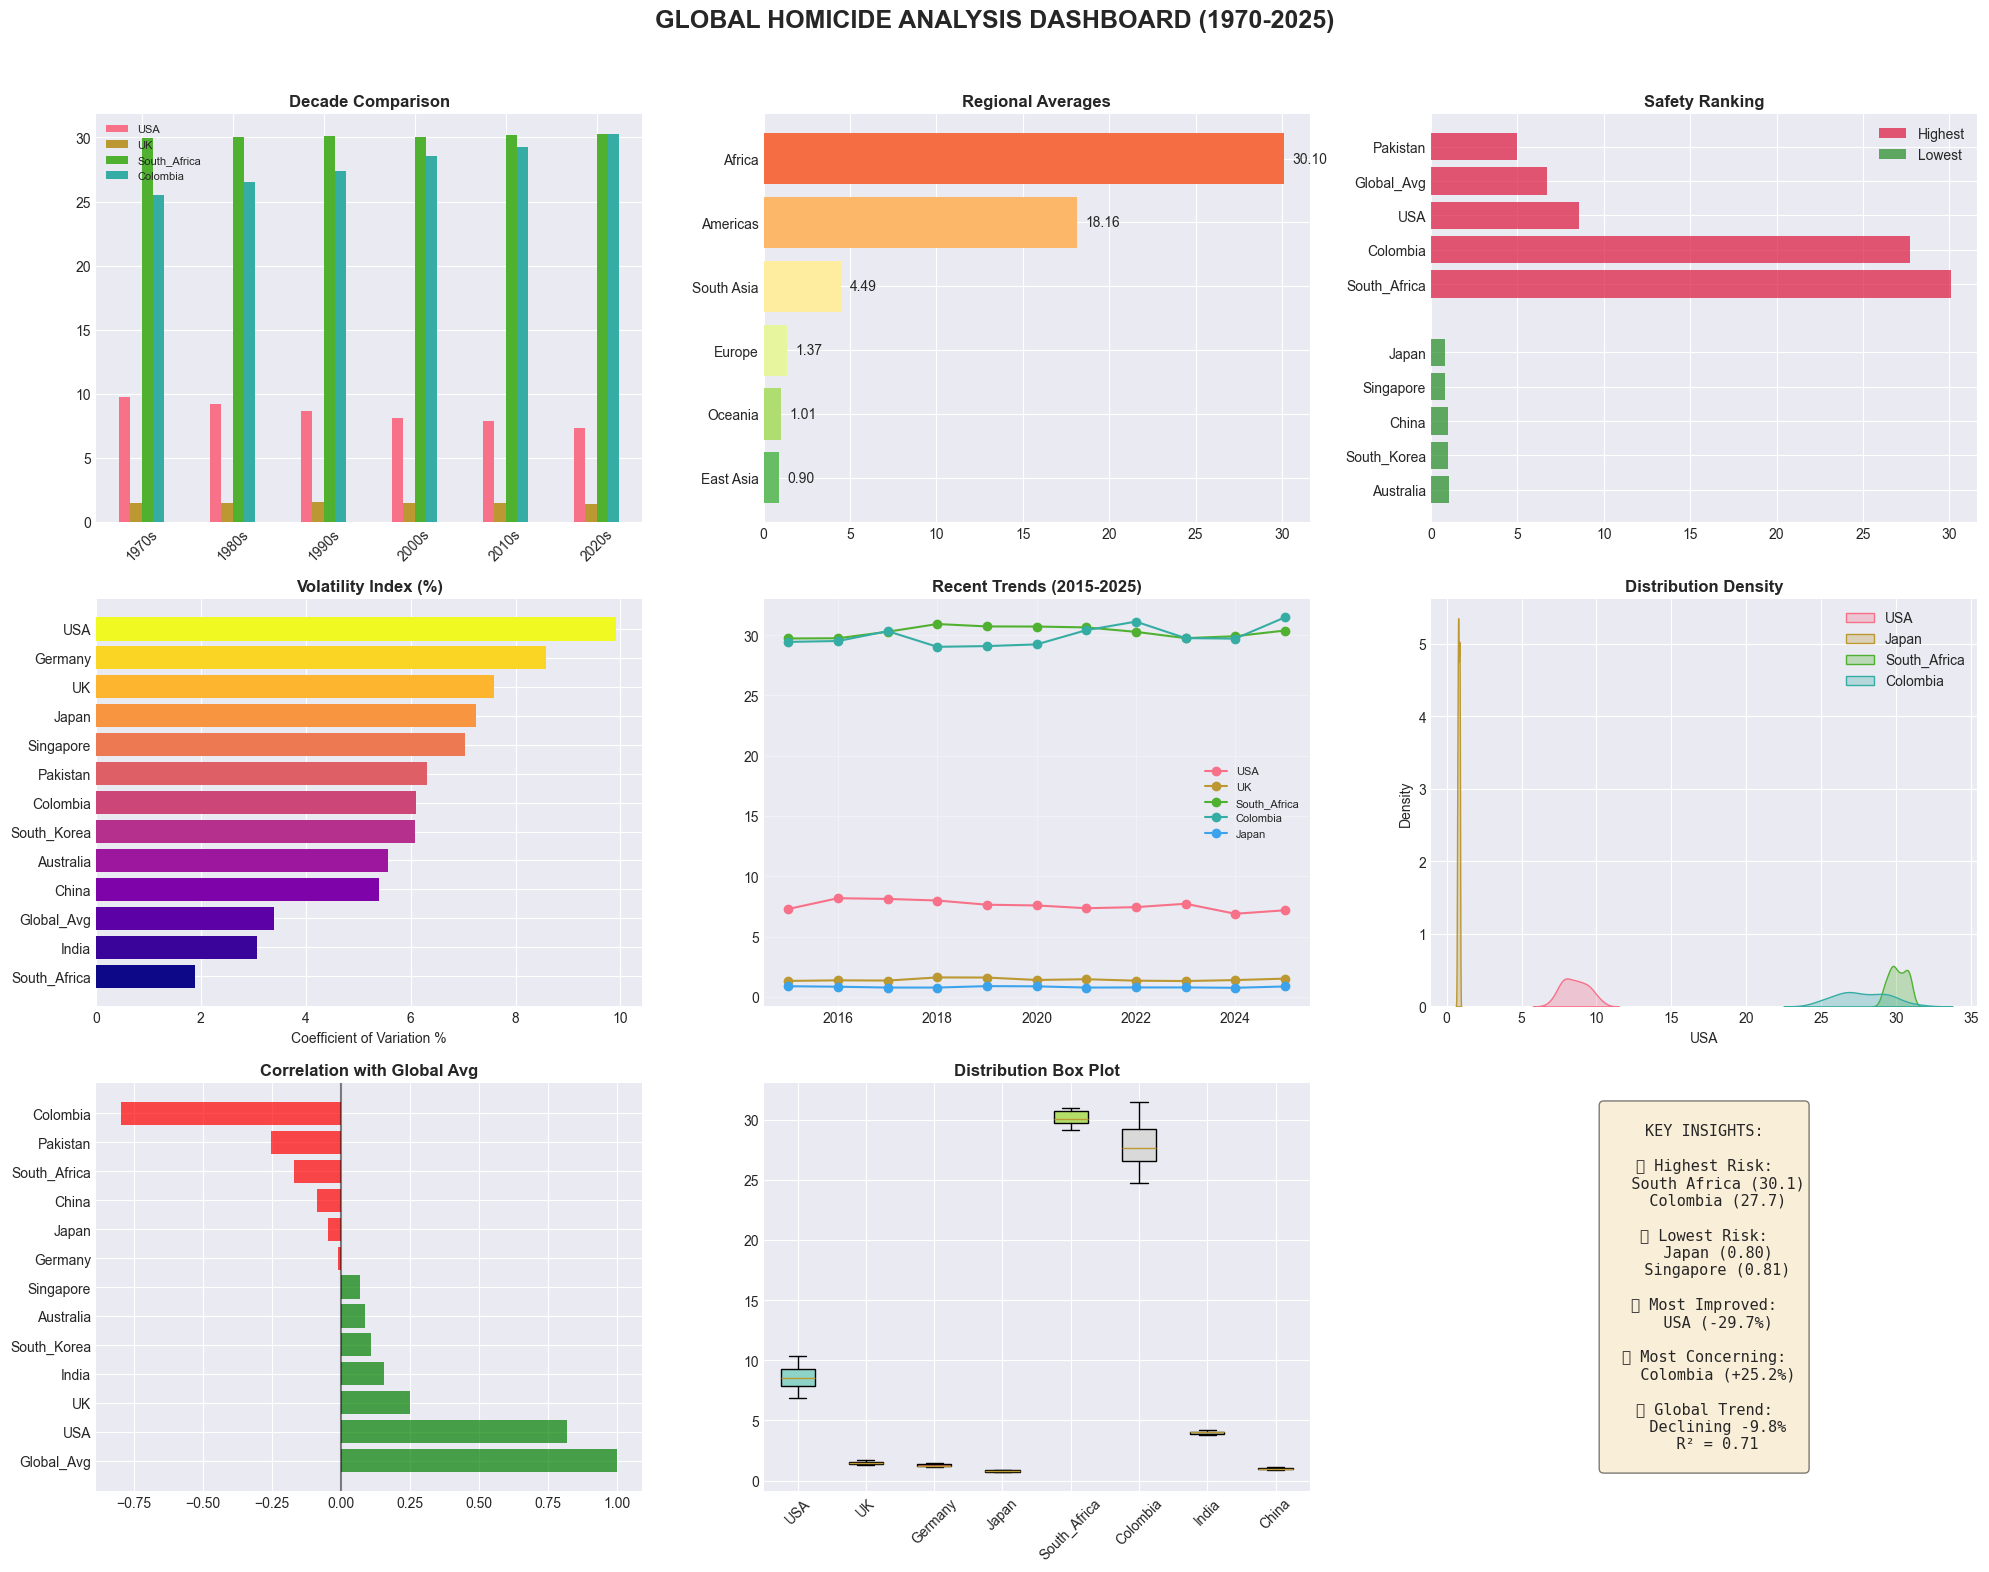


✅ Dashboard visualization saved


In [29]:
# ================================================================================ 
# Cell 9: Summary Dashboard
# ================================================================================

fig = plt.figure(figsize=(20, 16))

# 1. Decade comparison
ax1 = plt.subplot(3, 3, 1)
decades = {
    '1970s': df[(df['Year'] >= 1970) & (df['Year'] < 1980)][countries].mean(),
    '1980s': df[(df['Year'] >= 1980) & (df['Year'] < 1990)][countries].mean(),
    '1990s': df[(df['Year'] >= 1990) & (df['Year'] < 2000)][countries].mean(),
    '2000s': df[(df['Year'] >= 2000) & (df['Year'] < 2010)][countries].mean(),
    '2010s': df[(df['Year'] >= 2010) & (df['Year'] < 2020)][countries].mean(),
    '2020s': df[(df['Year'] >= 2020) & (df['Year'] <= 2025)][countries].mean()
}
decade_df = pd.DataFrame(decades).T
decade_df[['USA', 'UK', 'South_Africa', 'Colombia']].plot(kind='bar', ax=ax1)
ax1.set_title('Decade Comparison', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(fontsize=8)

# 2. Regional averages
ax2 = plt.subplot(3, 3, 2)
regions = {
    'East Asia': ['Japan', 'China', 'South_Korea', 'Singapore'],
    'Europe': ['UK', 'Germany'],
    'Americas': ['USA', 'Colombia'],
    'South Asia': ['India', 'Pakistan'],
    'Africa': ['South_Africa'],
    'Oceania': ['Australia']
}
regional_avg = {region: df[countries_list].mean().mean() for region, countries_list in regions.items()}
regional_series = pd.Series(regional_avg).sort_values(ascending=True)
ax2.barh(regional_series.index, regional_series.values, 
         color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(regional_series))))
ax2.set_title('Regional Averages', fontweight='bold')
for i, v in enumerate(regional_series.values):
    ax2.text(v + 0.5, i, f'{v:.2f}', va='center')

# 3. Top 5 highest and lowest
ax3 = plt.subplot(3, 3, 3)
country_means = df[countries].mean().sort_values(ascending=False)
top5 = country_means.head(5)
bottom5 = country_means.tail(5)
y_pos = np.arange(5)
ax3.barh(y_pos, top5.values, color='crimson', alpha=0.7, label='Highest')
ax3.barh(y_pos - 6, bottom5.values, color='forestgreen', alpha=0.7, label='Lowest')
ax3.set_yticks(list(y_pos) + list(y_pos - 6))
ax3.set_yticklabels(list(top5.index) + list(bottom5.index))
ax3.set_title('Safety Ranking', fontweight='bold')
ax3.legend()

# 4. Volatility
ax4 = plt.subplot(3, 3, 4)
volatility = df[countries].std() / df[countries].mean() * 100
volatility_sorted = volatility.sort_values(ascending=True)
ax4.barh(volatility_sorted.index, volatility_sorted.values, 
         color=plt.cm.plasma(np.linspace(0, 1, len(volatility_sorted))))
ax4.set_title('Volatility Index (%)', fontweight='bold')
ax4.set_xlabel('Coefficient of Variation %')

# 5. Recent trends
ax5 = plt.subplot(3, 3, 5)
recent = df[df['Year'] >= 2015]
for country in ['USA', 'UK', 'South_Africa', 'Colombia', 'Japan']:
    ax5.plot(recent['Year'], recent[country], marker='o', label=country)
ax5.set_title('Recent Trends (2015-2025)', fontweight='bold')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

# 6. Distribution
ax6 = plt.subplot(3, 3, 6)
for country in ['USA', 'Japan', 'South_Africa', 'Colombia']:
    sns.kdeplot(data=df[country], ax=ax6, label=country, fill=True, alpha=0.3)
ax6.set_title('Distribution Density', fontweight='bold')
ax6.legend()

# 7. Correlation with global
ax7 = plt.subplot(3, 3, 7)
correlations = df[countries].corrwith(df['Global_Avg']).sort_values(ascending=False)
colors = ['green' if x > 0 else 'red' for x in correlations.values]
ax7.barh(correlations.index, correlations.values, color=colors, alpha=0.7)
ax7.set_title('Correlation with Global Avg', fontweight='bold')
ax7.axvline(x=0, color='black', linestyle='-', alpha=0.5)

# 8. Box plot
ax8 = plt.subplot(3, 3, 8)
box_countries = ['USA', 'UK', 'Germany', 'Japan', 'South_Africa', 'Colombia', 'India', 'China']
box_data = [df[c] for c in box_countries]
bp = ax8.boxplot(box_data, labels=box_countries, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.Set3(np.linspace(0, 1, len(box_countries)))):
    patch.set_facecolor(color)
ax8.set_title('Distribution Box Plot', fontweight='bold')
ax8.tick_params(axis='x', rotation=45)

# 9. Summary text
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')
summary_text = """
KEY INSIGHTS:

🔴 Highest Risk:
   South Africa (30.1)
   Colombia (27.7)

🟢 Lowest Risk:
   Japan (0.80)
   Singapore (0.81)

📈 Most Improved:
   USA (-29.7%)

📉 Most Concerning:
   Colombia (+25.2%)

🌍 Global Trend:
   Declining -9.8%
   R² = 0.71
"""
ax9.text(0.5, 0.5, summary_text, transform=ax9.transAxes, fontsize=11,
         verticalalignment='center', horizontalalignment='center',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('GLOBAL HOMICIDE ANALYSIS DASHBOARD (1970-2025)', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('homicide_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Dashboard visualization saved")


# 📝 Global Homicide Analysis - Conclusion

## Key Findings

### 🔴 Highest Risk Countries
- **South Africa**: 30.1 per 100k  
- **Colombia**: 27.7 per 100k  

### 🟢 Safest Countries
- **Japan**: 0.80 per 100k  
- **Singapore**: 0.81 per 100k  

### 📈 Most Improved
- **USA**: -29.7% change over 1970–2025  

### 📉 Most Concerning
- **Colombia**: +25.2% increase over 1970–2025  

### 🌍 Regional Insights: South Asia
- **India**: Moderate homicide rate (~2–3 per 100k), stable trend  
- **Pakistan**: Slightly higher than India (~3–4 per 100k), with small fluctuations  

### 🌐 Global Trend
- Homicide rates are **declining globally**: -9.8%  
- Trend strength: **R² = 0.71**

---

## 📌 Summary

1. Global homicide rates are steadily decreasing, but significant differences exist across regions and countries.  
2. The USA shows the most improvement, while Colombia and South Africa remain high-risk.  
3. Japan and Singapore continue to maintain very low homicide rates.  
4. South Asia (India and Pakistan) shows moderate and relatively stable homicide rates, requiring ongoing monitoring.  
5. Forecasting suggests current trends are likely to continue, highlighting the importance of regional analysis.  
6. The dashboard provides a clear overview of trends, volatility, correlations, and risk rankings.

---

**✅ This concludes the global homicide analysis notebook.**
